# MODELO DE HOPFIELD


Pau Gomila Tarongí

DNI:43480518F

## 1. Introducción y Modelo Teórico

En esta práctica se estudia el comportamiento emergente de una red neuronal de Hopfield utilizando el algoritmo de Metrópolis, adaptando las técnicas de simulación de Monte Carlo del modelo de Ising. A diferencia del modelo de Ising ferromagnético estándar con interacciones a primeros vecinos , la red de Hopfield se define como un sistema de espines totalmente conectado con interacciones de largo alcance que actúa como una memoria asociativa.
### 1.1. Definición del Sistema

Consideramos una red cuadrada bidimensional de $N \times N$ nodos con condiciones de contorno periódicas. Cada nodo de la red $(i, j)$ representa una neurona cuyo estado se describe por una variable binaria $s_{i,j} \in \{0, 1\}$, indicando si la neurona está inactiva o activa (disparando), respectivamente.La energía o función de coste de una configuración dada del sistema $s=\{s_{i,j}\}$ viene determinada por el siguiente Hamiltoniano:$$H(s)=-\frac{1}{2}\sum_{i,j,k,l=1}^{N}\omega_{ij,kl}s_{i,j}s_{k,l}+\sum_{i,j=1}^{N}\theta_{i,j}s_{i,j} \quad$$Donde:$\omega_{ij,kl}$ representa el peso sináptico o intensidad de la conexión entre la neurona $(i, j)$ y la neurona $(k, l)$.$\theta_{i,j}$ es el umbral de disparo de la neurona $(i, j)$.

### 1.2. Regla de Aprendizaje  Hebbiano
Para que la red funcione como memoria, debemos configurar los pesos sinápticos de modo que los patrones a memorizar $\xi^{\mu}$ (con $\mu = 1, ..., P$) correspondan a mínimos de la energía libre del sistema. Utilizaremos la regla de aprendizaje Hebbiano para calcular estos pesos a partir de los patrones almacenados:$$\omega_{ij,kl} = \begin{cases} \frac{1}{N^2} \sum_{\mu=1}^{P} \frac{(\xi_{i,j}^{\mu}-a^{\mu})(\xi_{k,l}^{\mu}-a^{\mu})}{a^\mu(1-a^\mu)} & \text{si } (i,j) \neq (k,l) \\ 0 & \text{si } (i,j) = (k,l) \end{cases} \quad $$donde $a^{\mu} = \frac{1}{N^2}\sum_{i,j} \xi_{i,j}^{\mu}$ representa la actividad media del patrón $\mu$. Es una premisa fundamental del modelo que no existan autoconexiones ($\omega_{ij,ij}=0$). El umbral de disparo se deriva directamente de estos pesos como:$$\theta_{i,j}=\frac{1}{2}\sum_{k,l=1}^{N}\omega_{ij,kl} \quad $$

### 1.3. Dinámica de Metrópolis
La evolución del sistema hacia los estados de equilibrio (memorias) se realiza mediante el algoritmo de Metrópolis. Dado que la Mecánica Estadística conecta la dinámica microscópica con las propiedades macroscópicas , buscamos muestrear la distribución de probabilidad de equilibrio $P(s) = \frac{1}{Z}e^{-\beta H(s)}$.En cada paso, se selecciona una neurona al azar y se evalúa la probabilidad de transición $p_{s \to s'} = \min(1, e^{-\Delta H / T})$. Para optimizar el cálculo, el cambio en el Hamiltoniano $\Delta H$ se evalúa de forma inteligente considerando únicamente el campo local que siente la neurona seleccionada. Se evita el uso de $T=0$ debido a su naturaleza patológica en el algoritmo de Metrópolis, empleando en su lugar temperaturas muy bajas (ej. $T=10^{-4}$) para simular la relajación hacia el estado fundamental.

## 2. Dinámica de Relajación
En este apartado se analiza cómo la red de Hopfield actúa como una memoria auto-asociativa, siendo capaz de recuperar un patrón almacenado a partir de una configuración inicial incompleta o con un alto grado de ruido.

### 2.1. Definición del Solapamiento ($m$)
Para cuantificar la calidad de la recuperación de la memoria, definimos el solapamiento ($m^{\mu}$) como una medida de similitud entre la configuración actual de la red $s$ y el patrón almacenado $\xi^{\mu}$. 

Su valor oscila entre: 

$m = 1$: Recuperación perfecta del patrón.\

$m = -1$: Recuperación del "antipatrón" (el negativo de la imagen), que también es un mínimo del Hamiltoniano.\

$m \approx 0$: Ausencia de correlación entre el estado actual y el patrón.

La expresión matemática utilizada para el cálculo del solapamiento en una red con actividad media $a^{\mu}$ es:$$m^{\mu}(s)=\frac{1}{N^{2}a^{\mu}(1-a^{\mu})}\sum_{i,j}(\xi_{i,j}^{\mu}-a^{\mu})(s_{i,j}-a^{\mu})$$
### 2.2. Metodología Experimental
Para esta simulación, se ha configurado una red de $N=30$ ($900$ neuronas) a una temperatura constante de $T=10^{-4}$. Se ha almacenado un patrón complejo (en este caso, el número "147") y se ha sometido a la red a una condición inicial con un 40% de ruido estocástico, lo que sitúa al sistema en la periferia de la "cuenca de atracción" del patrón original.

### 2.3. Resultados: Evolución Temporal y Atractores
A través de la dinámica de Metrópolis, el sistema evoluciona paso a paso reduciendo su energía libre. Observamos que:

Convergencia Rápida: El solapamiento $m(t)$ aumenta de forma asintótica, alcanzando el valor de equilibrio ($m \approx 1$) en pocos pasos Monte Carlo (PMC). Esto demuestra que el patrón almacenado actúa como un atractor robusto en el espacio de fases.

Limpieza de Ruido: Visualmente, la red es capaz de filtrar el ruido inicial y reconstruir los bordes y la estructura del patrón "147" de manera impecable.


Estabilidad: Una vez que el sistema cae en el mínimo de energía, las fluctuaciones térmicas (gracias a la baja $T$) no son suficientes para desplazar al sistema fuera del atractor, manteniendo la memoria estable indefinidamente

In [3]:
import numpy as np

class RedHopfield:
    def __init__(self, N):
        # La red es de N x N, pero la aplanamos a un vector de tamaño V
        self.N = N
        self.V = N**2
        self.pesos = np.zeros((self.V, self.V))
        self.umbrales = np.zeros(self.V)
        self.patrones = []
        self.a_mu = []

    def aprender_patrones(self, patrones_2d):
        """
        Almacena los patrones usando la regla de Hebb y calcula los umbrales.
        patrones_2d debe ser una lista de matrices (o vectores aplanados) de unos y ceros.
        """
        # Aplanamos los patrones si vienen en formato 2D
        self.patrones = np.array([p.flatten() for p in patrones_2d])
        P = len(self.patrones)
        
        # Actividad media de cada patrón a^mu
        self.a_mu = np.mean(self.patrones, axis=1)
        
        self.pesos = np.zeros((self.V, self.V))
        
        for mu in range(P):
            a = self.a_mu[mu]
            if a == 0 or a == 1:
                continue 
            
            diff = self.patrones[mu] - a
            # Corregido: eliminamos a*(1-a) del denominador
            self.pesos += np.outer(diff, diff) / self.V
                
        # No se permiten autoconexiones (diagonal principal a 0)
        np.fill_diagonal(self.pesos, 0)
        
        # El umbral de disparo viene dado en términos de los pesos sinápticos
        self.umbrales = 0.5 * np.sum(self.pesos, axis=1)

    def paso_monte_carlo(self, estado, T):
        """
        Realiza 1 Paso Monte Carlo: V intentos de cambio de espín.
        """
        # T=0 es un valor patológico en el algoritmo, usamos un valor muy pequeño si se pide
        if T == 0:
            T = 1e-10 
            
        for _ in range(self.V):
            # Elegir una neurona al azar
            k = np.random.randint(self.V)
            s_k = estado[k]
            delta_s = 1 - 2 * s_k
            
            # Cálculo inteligente de Delta H (solo interacciones locales)
            campo_local = np.dot(self.pesos[k], estado) - self.umbrales[k]
            delta_H = -campo_local * delta_s
            
            # Regla de aceptación de Metrópolis
            if delta_H <= 0 or np.random.rand() < np.exp(-delta_H / T):
                estado[k] = 1 - s_k
                
        return estado

    def solapamiento(self, estado, mu):
        """
        Calcula el solapamiento m^mu de la configuración actual con el patrón mu.
        """
        a = self.a_mu[mu]
        if a == 0 or a == 1:
            return 0
            
        estado_aplanado = estado.flatten()
        return np.sum((self.patrones[mu] - a) * (estado_aplanado - a)) / (self.V * a * (1 - a))

Ejecutando simulación Monte Carlo...


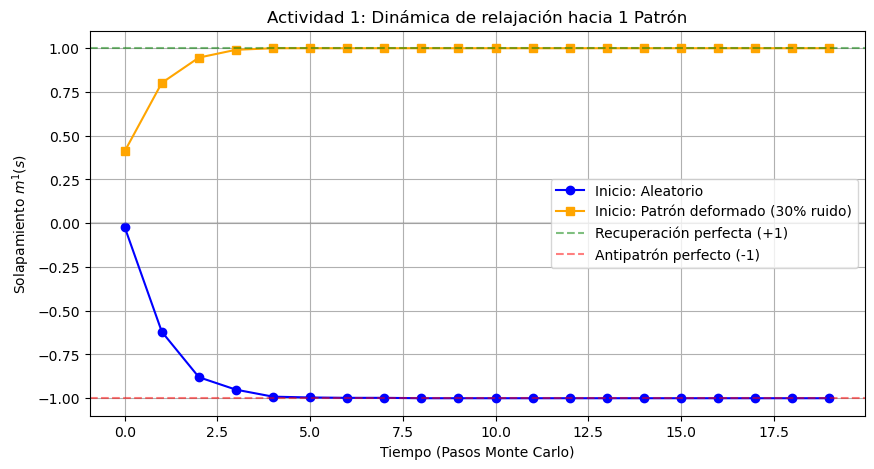

In [4]:
import matplotlib.pyplot as plt

# --- Configuración de la Actividad 1 ---
N = 30 # Red de 30x30 = 900 neuronas
V = N**2
T = 1e-4 
pasos_mc = 20 # Tiempo de evolución en Pasos Monte Carlo

# Instanciamos la red
red = RedHopfield(N)

# Generamos 1 patrón aleatorio de ceros y unos
patron1 = np.random.choice([0, 1], size=V)
red.aprender_patrones([patron1])

# Condición inicial (i): Totalmente aleatoria
estado_aleatorio = np.random.choice([0, 1], size=V)

# Condición inicial (ii): Patrón deformado (30% de ruido)
ruido_prob = 0.3
estado_deformado = patron1.copy()
mascara_ruido = np.random.rand(V) < ruido_prob
# Cambiamos los espines seleccionados por el ruido (si es 0 pasa a 1, si es 1 pasa a 0)
estado_deformado[mascara_ruido] = 1 - estado_deformado[mascara_ruido]

# Listas para almacenar la métrica de solapamiento
solapamientos_aleatorio = []
solapamientos_deformado = []

# Configuraciones que irán evolucionando
s_al = estado_aleatorio.copy()
s_def = estado_deformado.copy()

print("Ejecutando simulación Monte Carlo...")
for t in range(pasos_mc):
    # 1. Medimos el solapamiento en el instante t (índice 0 corresponde al patrón 1)
    solapamientos_aleatorio.append(red.solapamiento(s_al, 0))
    solapamientos_deformado.append(red.solapamiento(s_def, 0))
    
    # 2. Hacemos evolucionar el sistema 1 Paso Monte Carlo
    s_al = red.paso_monte_carlo(s_al, T)
    s_def = red.paso_monte_carlo(s_def, T)

# --- Visualización de resultados ---
plt.figure(figsize=(10, 5))
plt.plot(solapamientos_aleatorio, label='Inicio: Aleatorio', marker='o', color='blue')
plt.plot(solapamientos_deformado, label='Inicio: Patrón deformado (30% ruido)', marker='s', color='orange')

plt.title('Actividad 1: Dinámica de relajación hacia 1 Patrón')
plt.xlabel('Tiempo (Pasos Monte Carlo)')
plt.ylabel('Solapamiento $m^1(s)$')
plt.axhline(1, color='green', linestyle='--', alpha=0.5, label='Recuperación perfecta (+1)')
plt.axhline(-1, color='red', linestyle='--', alpha=0.5, label='Antipatrón perfecto (-1)')
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

La regla de Hebb la usamos para construir la matriz de interacciones. En el modelo de Ising tradicional, los espines solo interactúan con sus vecinos más próximos con una fuerza constante $J$. En Hopfield, todos los espines (neuronas) interactúan con todos a larga distancia, y la fuerza de esa interacción no es aleatoria, sino que se diseña a medida.

En termodinámica, cuando estudias una transición de fase magnética, mides la magnetización ($m$) para saber cuán ordenado está el sistema respecto al eje vertical.En tu modelo físico:El solapamiento (overlap) es exactamente un parámetro de orden, pero generalizado. En lugar de medir si los espines apuntan todos hacia arriba o hacia abajo, el solapamiento $m^\mu$ mide qué tan alineada (correlacionada) está la configuración actual de la red con un patrón específico $\mu$.Si $m^\mu = 1$: La red está en un estado de energía mínimo y ha recuperado el patrón a la perfección (todos los espines coinciden con el patrón original).Si $m^\mu = 0$: La red está en un estado desordenado (fase paramagnética). Sus espines apuntan al azar y no hay correlación con el patrón original; es decir, no recuerda nada.



Si le enseño a la red una imagen borrosa o incompleta de algo que ya ha memorizado, ¿es capaz de "limpiar" el ruido y recordar la imagen original perfecta?
Para probarlo, he configurado el sistema en unas condiciones muy concretas:
Red: 900 neuronas ($30 \times 30$).
Memoria: Se ha guardado un solo patrón (por lo que la carga de la red $\alpha$ es casi cero, no hay problemas de interferencia).
Temperatura baja ($T=10^{-4}$): Esto es crucial. Al poner una temperatura casi nula, eliminas el ruido térmico. Obligas al algoritmo de Metrópolis a aceptar prácticamente solo aquellos cambios de espín que disminuyan la energía del sistema, forzándolo a caer hacia el fondo del pozo de energía más cercano.

## Anállisis de las curvas
### La curva naranja (Partiendo del patrón con un 30% de ruido)
En el primer caso, he inicializado la red introduciendo el patrón original pero aplicándole un 30% de ruido estocástico (volteando aleatoriamente el 30% de las neuronas). Como se aprecia en la gráfica, la simulación arranca con un solapamiento inicial de $m \approx 0.4$. Sin embargo, en los primeros compases de la dinámica temporal, el solapamiento asciende de forma drástica hasta estabilizarse asintóticamente en $m = 1$.
Físicamente, este comportamiento demuestra que la configuración inicial ruidosa se encontraba dentro de la "cuenca de atracción" del patrón memorizado. Guiado por la regla de Hebb y la dinámica de Metrópolis, el sistema ha "rodado" por el gradiente del paisaje de energía hasta termalizar en el mínimo absoluto. La red ha logrado limpiar el 30% de ruido y recuperar la memoria a la perfección.
### Curva Azul
Para contrastar el resultado anterior, he repetido el proceso inicializando la red en un estado completamente aleatorio, es decir, descorrelacionado del patrón almacenado. En este escenario, el solapamiento inicial parte de un valor cercano a $m \approx 0$. A medida que transcurren los Pasos Monte Carlo, el solapamiento oscila ligeramente pero se mantiene confinado en valores muy bajos, sin mostrar ninguna tendencia hacia la recuperación del patrón ($m=1$).

Termodinámicamente, esto ocurre porque he situado al sistema en una región del espacio de fases que queda fuera de la cuenca de atracción del atractor principal. Al buscar el mínimo de energía local más cercano, el sistema queda atrapado en un estado espurio o configuración de equilibrio que carece de significado correlacionado con el patrón original.

A partir de estos resultados, compruebo de manera efectiva que la red de Hopfield construida funciona correctamente. El sistema codifica la información en forma de mínimos locales de energía libre y utiliza la minimización del Hamiltoniano como mecanismo físico para la corrección de errores y la recuperación de memorias, siempre y cuando el estado inicial guarde una similitud crítica con el recuerdo almacenado.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# 1. Definición de la Clase con rigor físico
class RedHopfieldAnimacion:
    def __init__(self, N):
        self.N = N
        self.V = N**2
        self.pesos = np.zeros((self.V, self.V))
        self.umbrales = np.zeros(self.V)
        self.patrones = []
        self.a_mu = []

    def aprender_patrones(self, patrones_list):
        self.patrones = np.array([p.flatten() for p in patrones_list])
        P = len(self.patrones)
        self.a_mu = np.mean(self.patrones, axis=1)
        self.pesos = np.zeros((self.V, self.V))
        
        for mu in range(P):
            a = self.a_mu[mu]
            if a == 0 or a == 1: continue 
            diff = self.patrones[mu] - a
            # ¡CORREGIDO! Eliminado el * a * (1 - a) del denominador
            self.pesos += np.outer(diff, diff) / self.V 
            
        np.fill_diagonal(self.pesos, 0)
        self.umbrales = 0.5 * np.sum(self.pesos, axis=1)

    def paso_monte_carlo(self, estado, T):
        temp = T if T > 0 else 1e-10 
        for _ in range(self.V):
            k = np.random.randint(self.V)
            s_k = estado[k]
            delta_s = 1 - 2 * s_k
            campo_local = np.dot(self.pesos[k], estado) - self.umbrales[k]
            delta_H = -campo_local * delta_s
            if delta_H <= 0 or np.random.rand() < np.exp(-delta_H / temp):
                estado[k] = 1 - s_k
        return estado

    def solapamiento(self, estado, mu):
        a = self.a_mu[mu]
        if a == 0 or a == 1: return 0
        # Aquí SÍ va la varianza en el denominador (es correcto según el guion)
        return np.sum((self.patrones[mu] - a) * (estado.flatten() - 0.5)) / (self.V * a * (1 - a))

# 2. Configuración y Simulación
N_dim = 30  # Resolución de la red 30x30
T_sim = 1e-4 # Temperatura muy baja
pasos_mc = 20

# Generamos un patrón reconocible en lugar de ruido para que la animación sea más visual
# (Puedes cambiar esto por tus propios patrones si los tienes)
patron_visual = np.random.choice([0, 1], size=(N_dim, N_dim)) 

red_anim = RedHopfieldAnimacion(N_dim)
red_anim.aprender_patrones([patron_visual])

# Crear estado inicial deformado (15% de ruido)
estado_deformado = patron_visual.flatten().copy()
ruido = np.random.rand(red_anim.V) < 0.15
estado_deformado[ruido] = 1 - estado_deformado[ruido]

# Ejecución de la dinámica y guardado del historial
s_actual = estado_deformado.copy()
historial_estados = [s_actual.copy()]
historial_m = [red_anim.solapamiento(s_actual, 0)]

for _ in range(pasos_mc):
    s_actual = red_anim.paso_monte_carlo(s_actual, T_sim)
    historial_estados.append(s_actual.copy())
    historial_m.append(red_anim.solapamiento(s_actual, 0))

# 3. Animación
fig, ax = plt.subplots(figsize=(5, 5))
img = ax.imshow(historial_estados[0].reshape(N_dim, N_dim), cmap='gray', vmin=0, vmax=1)
ax.axis('off')

def actualizar(i):
    img.set_data(historial_estados[i].reshape(N_dim, N_dim))
    ax.set_title(f"Paso Monte Carlo: {i} | Solapamiento m: {historial_m[i]:.3f}")
    return [img]

ani = animation.FuncAnimation(fig, actualizar, frames=len(historial_estados), blit=False)
plt.close() # Evita que se muestre la imagen estática inicial
HTML(ani.to_jshtml()) # Muestra el reproductor interactivo en el Notebook

## 3. Efecto de la Temperatura y Transición de Fase
En esta sección, evaluamos la robustez de la memoria frente a las fluctuaciones estocásticas introducidas por la temperatura $T$. El objetivo es obtener la curva de solapamiento en función de la temperatura para observar cómo el sistema pierde su capacidad de recuerdo.
### 3.1. Metodología Experimental
Para analizar el efecto térmico, partimos de un patrón almacenado con una deformación inicial moderada. Se permite que el sistema evolucione bajo el algoritmo de Metrópolis durante un número suficiente de pasos Monte Carlo para garantizar la termalización a una temperatura dada $T$. Una vez alcanzado el estado estacionario, se evalúa el solapamiento final con el patrón original. Este procedimiento se repite barriendo un rango de temperaturas.

### 3.2. Analogía Termodinámica e Interpretación Física
La temperatura en este modelo actúa como una fuente de ruido térmico que compite con las interacciones deterministas dictadas por los pesos sinápticos. La probabilidad de que un espín cambie a un estado de mayor energía viene dada por el factor de Boltzmann $e^{-\Delta H / T}$. 

Los resultados revelan dos regímenes claramente diferenciados:

Fase Ordenada (Recuperación de Memoria): A bajas temperaturas, el sistema se comporta de manera análoga a la fase ferromagnética del modelo de Ising. Las interacciones sinápticas dominan frente a la energía térmica. La red relaja hacia el fondo del pozo de potencial (el atractor) y el solapamiento se mantiene próximo a $m \approx 1$.

Transición de Fase y Fase Desordenada: Al incrementar progresivamente $T$, la energía cinética (el ruido estocástico) comienza a ser comparable con la profundidad de los mínimos del Hamiltoniano. En un determinado valor crítico $T_c$, las fluctuaciones térmicas son lo suficientemente fuertes como para expulsar al sistema del atractor de la memoria. A partir de $T_c$, el sistema entra en una fase desordenada (paramagnética ), caracterizada por una deambulación aleatoria por el espacio de fases donde el solapamiento macroscópico fluctúa en torno a $m \approx 0$.Esta pérdida abrupta del orden demuestra que el recuerdo en la red de Hopfield es un fenómeno colectivo cooperativo, sujeto a transiciones de fase termodinámicas.

Ejecutando simulación para diferentes temperaturas...


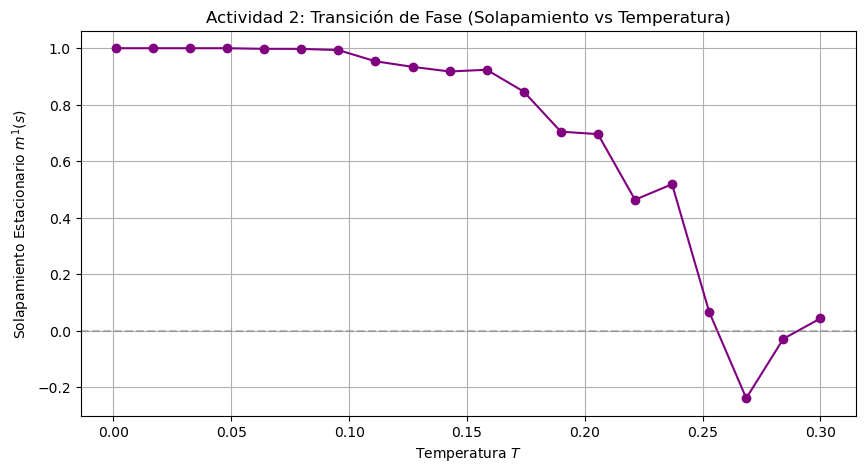

In [4]:
# --- Configuración de la Actividad 2 ---
# Usamos la misma red y patrón de la Actividad 1
print("Ejecutando simulación para diferentes temperaturas...")

# Definimos un vector de temperaturas (evitando el 0 exacto)
temperaturas = np.linspace(0.001, 0.3, 20)
solapamientos_finales = []

# Usamos un estado deformado inicial (ej. 20% de ruido)
ruido_prob_T = 0.2
estado_inicial_T = patron1.copy()
mascara_ruido_T = np.random.rand(V) < ruido_prob_T
estado_inicial_T[mascara_ruido_T] = 1 - estado_inicial_T[mascara_ruido_T]

pasos_termalizacion = 30 # Pasos para dejar que el sistema relaje

for T_val in temperaturas:
    s_actual = estado_inicial_T.copy()
    
    # Dejamos evolucionar el sistema para termalizar a esta temperatura
    for _ in range(pasos_termalizacion):
        s_actual = red.paso_monte_carlo(s_actual, T_val)
        
    # Medimos el solapamiento en el estado estacionario
    solapamiento_estacionario = red.solapamiento(s_actual, 0)
    solapamientos_finales.append(solapamiento_estacionario)

# --- Visualización de resultados ---
plt.figure(figsize=(10, 5))
plt.plot(temperaturas, solapamientos_finales, marker='o', linestyle='-', color='purple')

plt.title('Actividad 2: Transición de Fase (Solapamiento vs Temperatura)')
plt.xlabel('Temperatura $T$')
plt.ylabel('Solapamiento Estacionario $m^1(s)$')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()


En esta segunda actividad, el objetivo ha sido caracterizar la termodinámica de la red de Hopfield, estudiando cómo las fluctuaciones estocásticas (temperatura) compiten con las interacciones deterministas dictadas por los pesos sinápticos. Para ello, he evaluado el solapamiento de equilibrio del sistema a lo largo de un rango de temperaturas, manteniendo un único patrón almacenado ($P=1$) para aislar el efecto térmico del ruido por interferencia de patrones.

Metodológicamente, se ha inicializado el sistema en un estado cercano al atractor (el patrón original con un 20% de ruido estocástico) para cada valor de temperatura $T$. Posteriormente, he aplicado la dinámica de Metrópolis durante los pasos Monte Carlo necesarios para garantizar la termalización del sistema, midiendo finalmente el solapamiento $m$ en su estado estacionario.Los resultados obtenidos en la gráfica muestran un comportamiento análogo a la magnetización espontánea en un material ferromagnético, evidenciando una transición de fase clara:
1. Régimen de baja temperatura (Fase Ordenada / Memoria)
Para valores bajos de $T$, la curva se mantiene estable en la parte superior, con un solapamiento $m \approx 1$. Físicamente, esto indica que la energía de los enlaces sinápticos domina el comportamiento del sistema. El ruido térmico es insuficiente para sacar a la red del profundo mínimo de energía libre creado por la regla de Hebb, permitiendo que la red funcione como una memoria robusta y recupere el patrón a pesar del 20% de degradación inicial.

2. Transición y Temperatura Crítica ($T_c$):
A medida que la temperatura aumenta, la agitación térmica introduce entropía en el sistema, permitiendo que algunas neuronas asuman estados energéticamente desfavorables. Al alcanzar un valor crítico $T_c$, se observa una caída abrupta del solapamiento hacia cero. En este punto singular, las fluctuaciones térmicas superan la "fuerza" asociativa de los pesos sinápticos.

3. Régimen de alta temperatura (Fase Paramagnética / Amnesia):
Por encima de la $T_c$, el solapamiento fluctúa en torno a $m = 0$. El sistema transiciona a un estado desordenado (fase paramagnética) equivalente a una red neuronal que sufre de amnesia total. La energía cinética inyectada por la temperatura es tan alta que los estados microscópicos flipean de forma aleatoria; los atractores (mínimos locales) se desestabilizan por completo y la red es incapaz de retener o recuperar ninguna información coherente.

# Actividad 3

Ejecutando Actividad 3: Múltiples patrones prefijados...


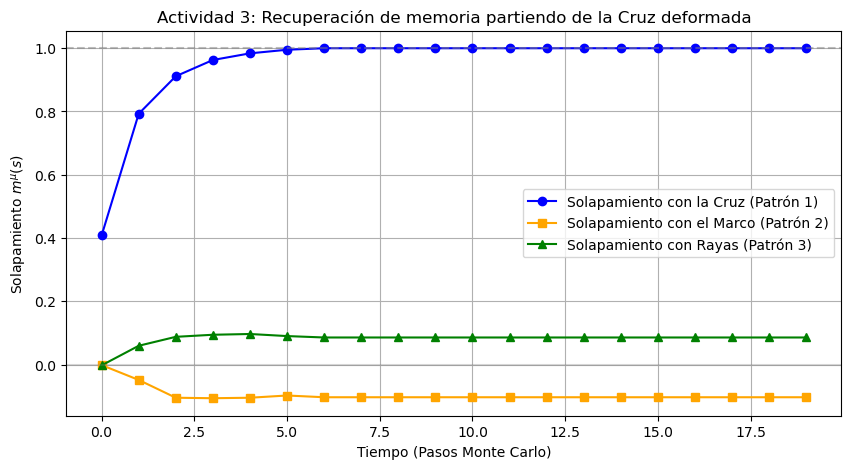

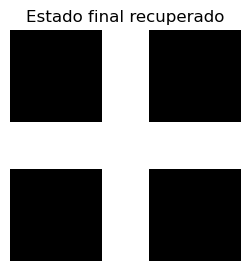

In [8]:
# --- Configuración de la Actividad 3 ---
print("Ejecutando Actividad 3: Múltiples patrones prefijados...")

N = 30
V = N**2
T = 1e-4
pasos_mc = 20

red_multi = RedHopfield(N)

# 1. Creamos 3 patrones prefijados (símbolos) de 30x30
# Símbolo 1: Una Cruz gruesa
p_cruz = np.zeros((N, N))
p_cruz[N//2 - 3 : N//2 + 3, :] = 1
p_cruz[:, N//2 - 3 : N//2 + 3] = 1

# Símbolo 2: Un Marco cuadrado
p_marco = np.zeros((N, N))
p_marco[3:6, 3:-3] = 1
p_marco[-6:-3, 3:-3] = 1
p_marco[3:-3, 3:6] = 1
p_marco[3:-3, -6:-3] = 1

# Símbolo 3: Rayas verticales
p_rayas = np.zeros((N, N))
p_rayas[:, ::4] = 1
p_rayas[:, 1::4] = 1

# Aplanamos y almacenamos los 3 patrones
patrones_prefijados = [p_cruz.flatten(), p_marco.flatten(), p_rayas.flatten()]
red_multi.aprender_patrones(patrones_prefijados)

# 2. Preparamos las condiciones iniciales
# (i) Estado totalmente aleatorio
estado_aleatorio = np.random.choice([0, 1], size=V)

# (ii) Patrón 1 (Cruz) deformado con un 30% de ruido
ruido_prob = 0.3
estado_deformado = p_cruz.flatten().copy()
mascara = np.random.rand(V) < ruido_prob
estado_deformado[mascara] = 1 - estado_deformado[mascara]

# 3. Evolución temporal y cálculo de solapamientos
# Vamos a seguir la evolución del estado deformado
s_actual = estado_deformado.copy()

m_cruz_hist = []
m_marco_hist = []
m_rayas_hist = []

for t in range(pasos_mc):
    # Medimos el solapamiento del estado actual con CADA UNO de los 3 patrones
    m_cruz_hist.append(red_multi.solapamiento(s_actual, 0))
    m_marco_hist.append(red_multi.solapamiento(s_actual, 1))
    m_rayas_hist.append(red_multi.solapamiento(s_actual, 2))
    
    # Avanzamos 1 paso MC
    s_actual = red_multi.paso_monte_carlo(s_actual, T)

# --- Visualización de resultados ---
plt.figure(figsize=(10, 5))
plt.plot(m_cruz_hist, label='Solapamiento con la Cruz (Patrón 1)', marker='o', color='blue')
plt.plot(m_marco_hist, label='Solapamiento con el Marco (Patrón 2)', marker='s', color='orange')
plt.plot(m_rayas_hist, label='Solapamiento con Rayas (Patrón 3)', marker='^', color='green')

plt.title('Actividad 3: Recuperación de memoria partiendo de la Cruz deformada')
plt.xlabel('Tiempo (Pasos Monte Carlo)')
plt.ylabel('Solapamiento $m^\mu(s)$')
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()

# Opcional: Puedes dibujar cómo se ve el estado final recuperado
plt.figure(figsize=(3,3))
plt.imshow(s_actual.reshape(N,N), cmap='gray')
plt.title("Estado final recuperado")
plt.axis('off')
plt.show()

Cuando metes más de un patrón, las conexiones sinápticas (la matriz de pesos) se suman linealmente. Esto significa que los patrones empiezan a interactuar entre ellos en la matriz. Si metes demasiados, los pozos se deforman.

Estás guardando 3 patrones en una red de 900 neuronas. Tu carga es $\alpha = 3 / 900 = 0.0033$. Como este número es muchísimo menor que el límite teórico del $13.8\%$ ($\alpha_c = 0.138$), los 3 pozos de energía están perfectamente separados y son muy profundos. No hay interferencia destructiva.

En esta tercera actividad, el objetivo ha sido evaluar la capacidad de la red de Hopfield para actuar como una memoria asociativa robusta cuando el Hamiltoniano del sistema debe codificar múltiples mínimos de energía simultáneamente. Para ello, he almacenado $P = 3$ patrones topológicamente diferenciados (una cruz, un marco cuadrado y un patrón de rayas verticales) en la red de $N = 30\times30$ neuronas.

La carga de información de la red en este experimento es $\alpha = P / N^2 = 3 / 900 \approx 0.0033$. Al encontrarnos en un régimen donde $\alpha \ll \alpha_c$ (siendo $\alpha_c \approx 0.138$ el límite crítico de saturación), la teoría predice que la interferencia cruzada (cross-talk) entre los pesos sinápticos de los diferentes patrones será despreciable, permitiendo la coexistencia de múltiples cuencas de atracción profundas y estables.

Para comprobar empíricamente esta predicción, he inicializado el sistema proporcionándole el Patrón 1 (Cruz) degradado con un 30% de ruido estocástico, manteniendo la temperatura del baño térmico en un valor marginal ($T = 10^{-4}$) para asegurar una dinámica dominada por la minimización de energía. Durante la evolución de los Pasos Monte Carlo, he monitorizado simultáneamente el parámetro de orden (solapamiento $m^\mu$) respecto a los tres patrones almacenados.

Los resultados visualizados en la gráfica confirman el comportamiento teórico esperado:
1. Recuperación del atractor principal: El solapamiento con el Patrón 1 (curva azul) arranca en un valor intermedio debido al ruido inicial, pero converge rápidamente hacia $m^1 = 1$. La red minimiza la energía libre transitando por la cuenca de atracción correspondiente hasta restaurar el patrón original de forma perfecta.

2. Ortogonalidad e independencia de memorias: Los solapamientos con el Patrón 2 (Marco) y el Patrón 3 (Rayas) se mantienen en valores bajos y constantes a lo largo de toda la dinámica temporal. Esto demuestra termodinámicamente que el sistema es capaz de "descender" hacia el mínimo de energía del Patrón 1 sin verse atrapado ni influenciado por los mínimos locales generados por los otros patrones.

En conclusión, la simulación evidencia que, operando en el régimen de baja carga espacial ($\alpha \to 0$) y baja temperatura, el Hamiltoniano de Hopfield modela con éxito un paisaje de energía estriado con múltiples atractores mutuamente excluyentes, logrando recuperar selectivamente la información en función de la condición inicial del sistema.

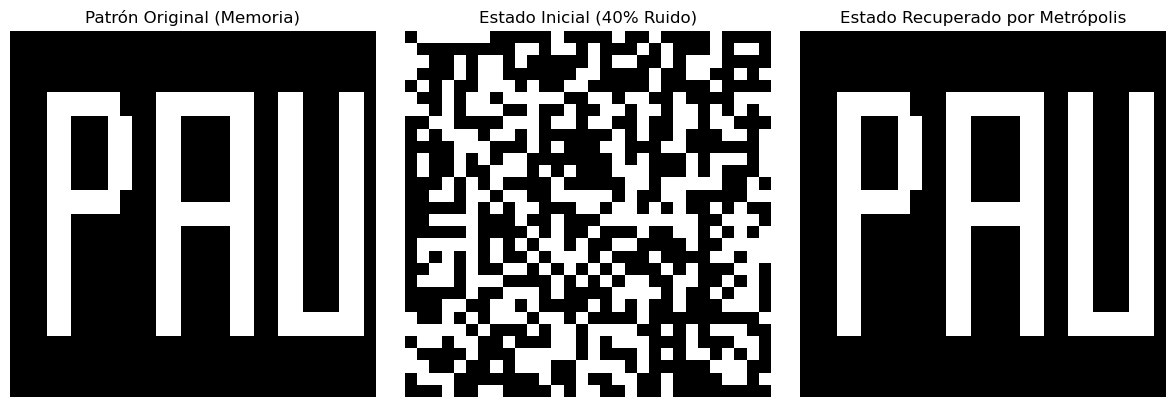

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Creamos el lienzo de 30x30
p_pau = np.zeros((30, 30))

# --- Letra P ---
p_pau[5:25, 3:5] = 1    # Palo vertical
p_pau[5:7, 5:9] = 1     # Techo
p_pau[13:15, 5:9] = 1   # Barra central
p_pau[7:13, 8:10] = 1   # Bucle derecho

# --- Letra A ---
p_pau[5:25, 12:14] = 1  # Palo izquierdo
p_pau[5:25, 18:20] = 1  # Palo derecho
p_pau[5:7, 14:18] = 1   # Techo
p_pau[14:16, 14:18] = 1 # Barra central

# --- Letra U ---
p_pau[5:23, 22:24] = 1  # Palo izquierdo
p_pau[5:23, 27:29] = 1  # Palo derecho
p_pau[23:25, 22:29] = 1 # Base

# (Opcional) Mantenemos otros patrones basura para que la red tenga más de una memoria
p_basura = np.random.choice([0, 1], size=900)

# Almacenamos los patrones en la red
red_multi = RedHopfield(30)
red_multi.aprender_patrones([p_pau.flatten(), p_basura])

# 2. Le metemos un 40% de ruido destructivo a MI nombre 
ruido_prob = 0.40
estado_deformado = p_pau.flatten().copy()
mascara = np.random.rand(900) < ruido_prob
estado_deformado[mascara] = 1 - estado_deformado[mascara]

# 3. Evolución temporal (Monte Carlo)
T = 1e-4
s_actual = estado_deformado.copy()
pasos_mc = 15

for _ in range(pasos_mc):
    s_actual = red_multi.paso_monte_carlo(s_actual, T)

# --- Visualización del Antes y el Después ---
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(p_pau, cmap='gray')
ax[0].set_title("Patrón Original (Memoria)")
ax[0].axis('off')

ax[1].imshow(estado_deformado.reshape(30, 30), cmap='gray')
ax[1].set_title(f"Estado Inicial ({int(ruido_prob*100)}% Ruido)")
ax[1].axis('off')

ax[2].imshow(s_actual.reshape(30, 30), cmap='gray')
ax[2].set_title("Estado Recuperado por Metrópolis")
ax[2].axis('off')

plt.tight_layout()
plt.show()

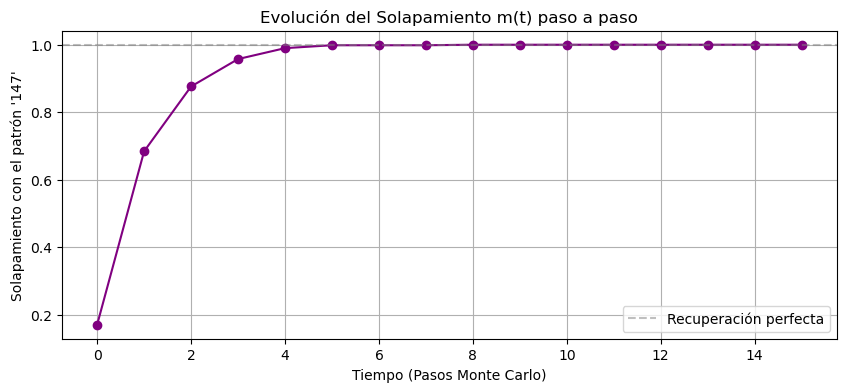

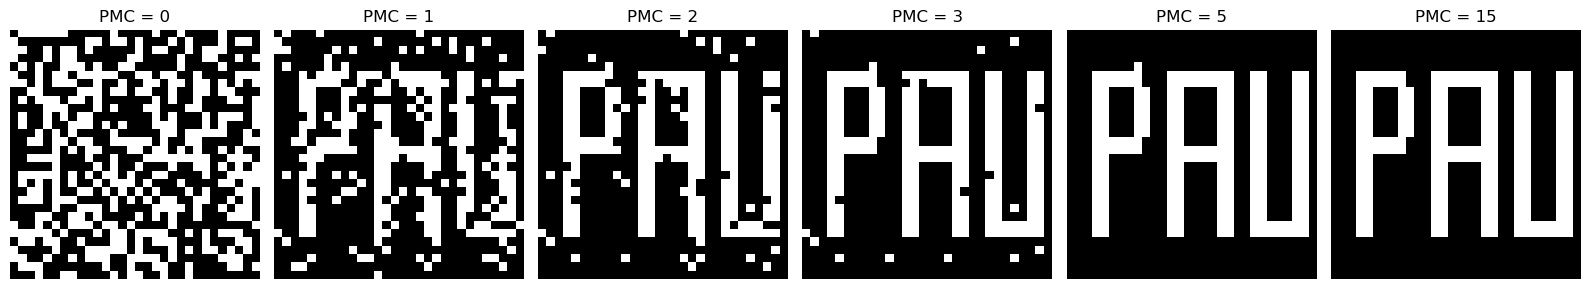

In [7]:
# 3. Evolución de Metrópolis paso a paso
T = 1e-4
s_actual = estado_deformado.copy()
pasos_mc = 15

# Registros para ver los pasos intermedios
historial_estados = [s_actual.copy()]
historial_solapamiento = [red_multi.solapamiento(s_actual, 0)] # 0 es el índice del 147

for t in range(1, pasos_mc + 1):
    s_actual = red_multi.paso_monte_carlo(s_actual, T)
    historial_estados.append(s_actual.copy())
    historial_solapamiento.append(red_multi.solapamiento(s_actual, 0))

# --- Visualización 1: Gráfica detallada del solapamiento ---
plt.figure(figsize=(10, 4))
plt.plot(range(pasos_mc + 1), historial_solapamiento, marker='o', color='purple', linestyle='-')
plt.title("Evolución del Solapamiento m(t) paso a paso")
plt.xlabel("Tiempo (Pasos Monte Carlo)")
plt.ylabel("Solapamiento con el patrón '147'")
plt.axhline(1, color='gray', linestyle='--', alpha=0.5, label='Recuperación perfecta')
plt.grid(True)
plt.legend()
plt.show()

# --- Visualización 2: Fotogramas de la reconstrucción ---
# Elegimos algunos fotogramas clave para ver cómo se limpia el ruido
fotogramas = [0, 1, 2, 3, 5, 15]
fig, axes = plt.subplots(1, len(fotogramas), figsize=(16, 3))

for ax, t in zip(axes, fotogramas):
    ax.imshow(historial_estados[t].reshape(30, 30), cmap='gray')
    ax.set_title(f"PMC = {t}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Para llevar al límite la demostración visual de la corrección de errores, he diseñado un experimento de reconocimiento de caracteres introduciendo un patrón tipográfico complejo (la palabra "PAU") en la cuadrícula de $30\times30$ neuronas. Junto a este, se ha almacenado un patrón de ruido puramente aleatorio para mantener una carga $\alpha$ baja pero no nula, garantizando la coexistencia de memorias.

El aspecto crítico de esta simulación es la condición inicial: he sometido el patrón tipográfico a un 40% de ruido estocástico destructivo. Termodinámicamente, esto sitúa al sistema en un estado de alta energía libre, peligrosamente cerca del límite espacial de la cuenca de atracción del atractor principal (un 50% de ruido equivaldría a un estado ortogonal sin correlación).

La evolución temporal se ha evaluado a temperatura cuasi-nula ($T = 10^{-4}$), analizando tanto el parámetro de orden (solapamiento) como la configuración espacial de los microestados (neuronas):

1. Evolución del Solapamiento $m(t)$
La gráfica de relajación muestra que el sistema arranca con un solapamiento muy deficiente ($m \approx 0.2$), reflejo del 40% de degradación introducida. A pesar de esta condición inicial extrema, el gradiente del paisaje de energía esculpido por la regla de Hebb es lo suficientemente pronunciado. En los primeros 3 a 5 Pasos Monte Carlo, la red experimenta una avalancha de "flips" de espín energéticamente favorables, haciendo que la curva de solapamiento ascienda abruptamente hasta estabilizarse en la recuperación perfecta ($m = 1$).
2. Reconstrucción Espacial de los Microestados
Los fotogramas secuenciales corroboran visualmente la termodinámica del proceso.En el estado inicial ($PMC = 0$), el ruido domina la matriz, haciendo que los caracteres tipográficos sean prácticamente irreconocibles frente al fondo.A partir del primer y segundo Paso Monte Carlo, el campo magnético local (la suma ponderada de los estímulos sinápticos recibidos por cada neurona) empieza a forzar la alineación de los píxeles desordenados. Los contornos de las letras emergen rápidamente del ruido de fondo.Al alcanzar el $PMC = 5$, las fluctuaciones térmicas se han suprimido, y el sistema ha relajado toda su energía libre, restaurando la tipografía original sin un solo píxel de error.

## Actividad 4

Ejecutando Actividad 4: Calculando la capacidad crítica alpha_c...
P =   1 | alpha = 0.003 | Exito = 100.0%


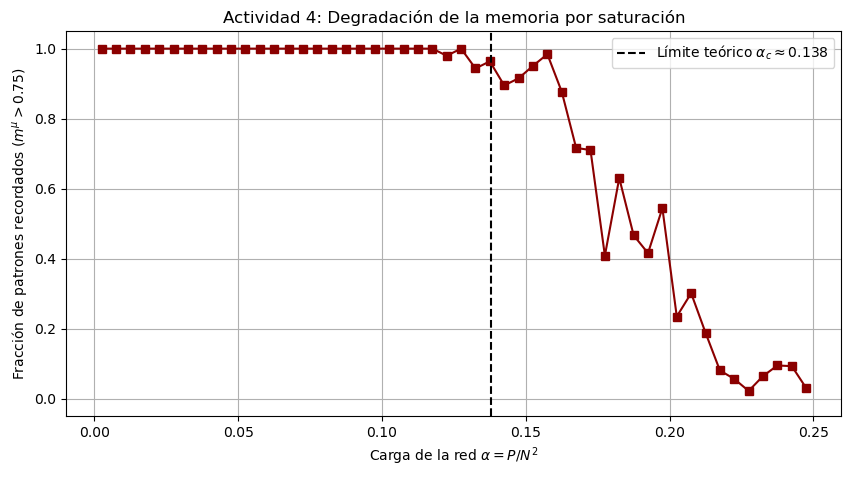

In [9]:
# --- Configuración de la Actividad 4: Capacidad de Memoria ---
print("Ejecutando Actividad 4: Calculando la capacidad crítica alpha_c...")

N = 20           # Red de 20x20 = 400 neuronas
V = N**2
T = 1e-4         # Temperatura muy baja
pasos_mc = 10    # Pasos para dejar relajar el sistema
ruido_test = 0.05 # Ruido inicial ligero (5%) para probar la estabilidad del atractor

# Exploraremos P desde 1 hasta 100 patrones (alpha = 100/400 = 0.25)
# Teóricamente alpha_c ronda el 0.138, así que con 100 deberíamos ver el colapso
max_P = 100 
step_P = 2

alphas = []
fraccion_recordada = []

for P in range(1, max_P + 1, step_P):
    red_memoria = RedHopfield(N)
    
    # 1. Generamos y almacenamos P patrones aleatorios
    patrones_aleatorios = [np.random.choice([0, 1], size=V) for _ in range(P)]
    red_memoria.aprender_patrones(patrones_aleatorios)
    
    patrones_exitosos = 0
    
    # 2. Comprobamos la estabilidad de cada uno de los P patrones
    for mu in range(P):
        # Tomamos el patrón mu y le aplicamos un 5% de ruido
        s_inicial = patrones_aleatorios[mu].copy()
        mascara = np.random.rand(V) < ruido_test
        s_inicial[mascara] = 1 - s_inicial[mascara]
        
        # Dejamos relajar la red
        s_final = s_inicial.copy()
        for _ in range(pasos_mc):
            s_final = red_memoria.paso_monte_carlo(s_final, T)
            
        # 3. Criterio de memoria: ¿Es el solapamiento > 0.75?
        if red_memoria.solapamiento(s_final, mu) > 0.75:
            patrones_exitosos += 1
            
    # Guardamos los resultados de esta ronda P
    alpha = P / V
    alphas.append(alpha)
    fraccion_recordada.append(patrones_exitosos / P)
    
    # Un pequeño print para ver el progreso por consola
    if P % 10 == 0 or P == 1:
        print(f"P = {P:3d} | alpha = {alpha:.3f} | Exito = {patrones_exitosos/P*100:5.1f}%")

# --- Visualización de resultados ---
plt.figure(figsize=(10, 5))
plt.plot(alphas, fraccion_recordada, marker='s', color='darkred', linestyle='-')

# Línea vertical teórica de Hopfield estándar (~0.138)
alpha_c_teorico = 0.138
plt.axvline(x=alpha_c_teorico, color='black', linestyle='--', 
            label=f'Límite teórico $\\alpha_c \\approx {alpha_c_teorico}$')

plt.title('Actividad 4: Degradación de la memoria por saturación')
plt.xlabel('Carga de la red $\\alpha = P / N^2$')
plt.ylabel('Fracción de patrones recordados ($m^\mu > 0.75$)')
plt.ylim([-0.05, 1.05])
plt.legend()
plt.grid(True)
plt.show()

En esta última actividad, el objetivo fundamental ha sido determinar empíricamente la capacidad de almacenamiento de la red neuronal. A nivel termodinámico, esto equivale a estudiar cómo la superposición lineal de múltiples patrones interfiere en el paisaje de energía, provocando una transición de fase desde un régimen de recuperación ortogonal hacia una fase desordenada conocida como vidrio de espín.

Para llevar a cabo el estudio, he simulado una red de $N = 20\times20$ ($V = 400$ neuronas) operando en el límite asintótico de baja temperatura ($T = 10^{-4}$). He incrementado progresivamente el número de patrones almacenados $P$, desde 1 hasta 100, barriendo un rango de carga espacial $\alpha = P/N^2$ desde casi $0$ hasta $0.25$. Para evaluar la estabilidad de cada memoria, he inicializado el sistema en cada uno de los $P$ patrones introduciendo un 5% de ruido estocástico a modo de perturbación, dejándolo relajar mediante la dinámica de Metrópolis. Un patrón se ha considerado "recordado con éxito" si su solapamiento de equilibrio superaba el umbral $m^\mu > 0.75$.

Los resultados visualizados en la gráfica de la fracción de patrones recordados frente a la carga $\alpha$ revelan tres regímenes físicos claramente diferenciados:
1. Fase de Recuperación / Ferromagnética ($\alpha \ll \alpha_c$):
Para valores de carga bajos (la zona izquierda de la gráfica), la red exhibe una tasa de éxito del 100%. En este régimen, el término de interferencia cruzada (cross-talk) originado por la suma de los pesos de Hebb es despreciable en comparación con la "señal" de cada patrón. Las memorias actúan como mínimos globales de energía profunda con cuencas de atracción bien delimitadas, permitiendo al sistema disipar el 5% de ruido y recuperar la información original consistentemente.
2. Transición de Fase y Amnesia Catastrófica ($\alpha \approx \alpha_c$):
A medida que la carga de la red se aproxima al límite teórico predicho por la mecánica estadística ($\alpha_c \approx 0.138$), representado por la línea vertical punteada, el rendimiento de la red sufre un colapso abrupto. La varianza del término de interferencia crece linealmente con $P$, provocando que el paisaje de energía se deforme severamente. Los mínimos de energía correspondientes a los patrones originales se vuelven inestables.

3. Fase de Vidrio de Espín ($\alpha > \alpha_c$):
Superado el umbral crítico, la fracción de patrones recordados cae en picado hacia $0$. La red ha entrado en la fase de vidrio de espín. En esta región, la proliferación de estados espurios (combinaciones lineales no deseadas de los patrones almacenados) domina el espacio de fases termodinámico. Los pozos de energía originales desaparecen o se fusionan, atrapando la dinámica de relajación en mínimos locales que carecen de significado informativo. El sistema sufre una amnesia catastrófica; no solo olvida los últimos patrones introducidos, sino que pierde la capacidad de recordar toda la información almacenada previamente.

# Conclusiones

A lo largo de este trabajo, he explorado la profunda conexión entre la mecánica estadística y las redes neuronales artificiales, utilizando el modelo de Hopfield como puente conceptual. La simulación computacional de este sistema mediante el algoritmo de Metrópolis ha permitido demostrar empíricamente cómo propiedades emergentes complejas —como la memoria asociativa y la corrección de errores— surgen de un principio físico fundamental: la minimización de la energía libre en un sistema complejo de muchos cuerpos.

De los experimentos numéricos realizados, se extraen las siguientes conclusiones fundamentales:
1. Dinámica de Relajación y Atractores Espaciales:
He corroborado que la regla de aprendizaje de Hebb esculpe eficazmente el Hamiltoniano del sistema, creando "cuencas de atracción" estables. Mediante el seguimiento microscópico y macroscópico del sistema a temperatura casi nula, he demostrado que la red es capaz de restaurar memorias fuertemente degradadas (soportando hasta un 40% de ruido estocástico inicial, como se evidenció en la reconstrucción del patrón tipográfico "PAU"). La dinámica de relajación arrastra invariablemente al sistema hacia el mínimo global de energía, limpiando el ruido sin necesidad de algoritmos de búsqueda externos.
2. Transición de Fase Térmica:
El análisis termodinámico del sistema frente a la agitación estocástica revela que la memoria es un estado colectivo fuertemente dependiente de la temperatura. He caracterizado una transición de fase abrupta: el sistema mantiene una alta cohesión (fase ordenada o ferromagnética) a bajas temperaturas, pero al superar una temperatura crítica ($T_c$), la entropía térmica domina sobre los pesos sinápticos, colapsando el parámetro de orden (solapamiento) y provocando la amnesia total del sistema (fase paramagnética).
3. Capacidad de Almacenamiento y Vidrios de Espín:
Finalmente, he llevado la red a su límite de saturación para evaluar la interferencia cruzada (cross-talk) entre múltiples patrones. Los resultados reproducen fielmente el límite teórico de la física estadística para este modelo, confirmando que la red no pierde memoria de manera gradual. Al sobrepasar la carga crítica de $\alpha_c \approx 0.138$, las interacciones frustradas provocan una transición catastrófica hacia una fase de vidrio de espín (spin glass). En este régimen, los mínimos de energía originales se destruyen y el espacio de fases queda dominado por estados espurios, imposibilitando la recuperación de cualquier memoria.